In [43]:
# Reload modules automatically
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [44]:
from pgpelib import PGPE
import numpy as np
from numbers import Real
import torch
from PIL import Image
import random
import requests
from io import BytesIO
import time
from matplotlib import cm
import matplotlib.pyplot as plt
from tqdm import tqdm
from os import path
import os
import json
from IPython.display import display, clear_output


# Utils imports
from utils.rasterize import *
from utils.load import get_segment_imgs, get_primitive_imgs
from utils.clipemb import CLIP_emb_from_IMG, CLIP_emb_from_TEXT
from utils.cma import clip_sol


DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

WIDTH = 300
HEIGHT = 300

CONTENT_DIR = './data'
RESULTS_DIR = path.join(CONTENT_DIR, 'results', 'pgpe')
SEGMENT_DIR = path.join(CONTENT_DIR, 'segment_img')
RW_PRIMITIVES_DIR = path.join(CONTENT_DIR, 'rw_primitives')
PRIMITIVE_DIR = path.join(CONTENT_DIR, 'primitives')

SEGMENT_IMGS = get_segment_imgs(SEGMENT_DIR, (WIDTH, HEIGHT))
RW_PRIMITIVES_IMGS = get_segment_imgs(RW_PRIMITIVES_DIR, (WIDTH, HEIGHT))
PRIMITIVE_IMGS = get_primitive_imgs(CONTENT_DIR, (WIDTH, HEIGHT))

In [45]:
a = np.array([[0.5, 0.2], [1, 0]])
b = np.array([[0.5, 0.2], [1, 0]]).T

# Normalized
np.linalg.norm(a-b) / len(a)

np.float64(0.5656854249492381)

In [46]:
def loop(es, max_val, primitives_selected, prompt_embedding, predictN, prompt_text, report_interval, x0, maxiter, gamma=0.4, test=False):
  x0 += 0.5

  # Check if the directory exists
  if not path.exists(path.join(RESULTS_DIR, prompt_text)):
    os.makedirs(path.join(RESULTS_DIR, prompt_text))
  
  with open(path.join(RESULTS_DIR, prompt_text, 'results.json'), 'w') as f:
    pass # Open to reset the file

  i = 0
  while i < maxiter:
      a = time.time()
      solutions = es.ask()
      rasterized_imgs = []
      all_empty_pixels = []
      all_diff = []
      all_straight = []

      b = time.time()
      for it, solution in enumerate(solutions):
        # Reshape (one for each primitive)
        solution = solution.reshape(-1, predictN)

        # Count how much shapes change from the first solution
        all_diff.append(np.linalg.norm((solution+0.5) - x0) / len(x0))

        solution = clip_sol(solution, max_val)
        
        # How straight the shapes are (aka 0 rotation)
        all_straight.append(np.average(solution[:,3]))

        img = rasterize_shapes(primitives_selected, solution, (WIDTH, HEIGHT))

        # Count empty pixels
        np_img = np.array(img)
        all_empty_pixels.append(np.sum(np_img[:, :, 3] == 0) / (np_img.shape[0] * np_img.shape[1])) # (300, 300, 4) -> 300 * 300 = 90000


        rasterized_imgs.append(Image.alpha_composite(
                                  #Image.new("RGBA", img.size, (54, 108, 176, 255)),  # Blue background
                                  Image.new("RGBA", img.size, (255, 255, 255, 255)),  # White background
                                  #Image.new("RGBA", img.size, (0, 0, 0, 0)),  # Black background
                                  img
                              ).convert("RGB"))

      rasterized_imgs = np.stack(rasterized_imgs, axis=0) # (population_size, 300, 300, 3)
      rasterized_imgs = torch.tensor(rasterized_imgs).permute(0, 3, 1, 2).to(DEVICE) # (population_size, 3, 300, 300)
      rasterized_emb = CLIP_emb_from_IMG(rasterized_imgs) # (population_size, 512)

      sim_loss = torch.nn.functional.cosine_similarity(rasterized_emb, prompt_embedding, dim=1)
      empty_pixel_loss = torch.tensor(all_empty_pixels).to(DEVICE) # (population_size)
      all_diff_loss = torch.tensor(all_diff).to(DEVICE) # (population_size)
      straight_loss = torch.tensor(all_straight).to(DEVICE) # (population_size)

      # (cos_similarity) + the count of empty pixels
      losses = (sim_loss) * (1 - gamma) + (1 - empty_pixel_loss) * gamma

      es.tell([l.item() for l in losses])

      # Save loss info (aka fitness)
      if not test:
        with open(path.join(RESULTS_DIR, prompt_text, 'results.json'), 'a') as f:
          json.dump({i: {
                          'full_loss': torch.mean(losses).item(),
                          'sim_loss': torch.mean(sim_loss).item(),
                          'pixel_loss': torch.mean(empty_pixel_loss).item(),
                        }
                      }, f)
          f.write('\n')

      
      # Update epoch
      i += 1

      if i % report_interval == 0:
        best_indx = losses.argmax()
        img = rasterized_imgs[best_indx].cpu().numpy()
        img = np.transpose(img, (1, 2, 0))
        img_pil = Image.fromarray(img.astype('uint8'), 'RGB')

        # Save best img
        if not test:
          img_pil.save(path.join(RESULTS_DIR, prompt_text, f'epoch_{i}.png'))

        clear_output(wait=True)  # Clear previous output
        display(img_pil)         # Display the new image
        print(f"Epoch {i} - Cosine Similarity: {sim_loss[best_indx].item()} - Empty pixels: {empty_pixel_loss[best_indx].item()} - Straight Loss: {straight_loss[best_indx].item()} - Time: {time.time() - a:.2f}s")
    


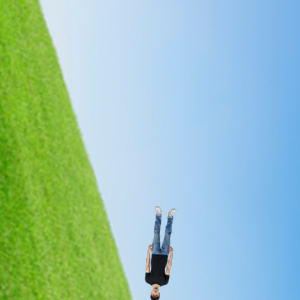

Epoch 495 - Cosine Similarity: 0.3028109669685364 - Empty pixels: 0.0 - Straight Loss: 0.1385805457830429 - Time: 1.05s


In [47]:

sigma = 0.1
maxiter = 500
popsize = 32
max_val = 0.5
predictN = 5

# Execute the loop for each prompt
for prompt_text, elems in list(RW_PRIMITIVES_IMGS.items())[0:]:
    x0 = np.zeros((len(elems), predictN))
    x0[0, 3] = -0.5 # No rotation

    pgpe = PGPE(
        # Length of each solution:
        solution_length=len(x0.flatten()),

        # Population size:
        popsize=popsize,

        # Initial center solution (i.e. initial mean of the search
        # distribution):
        center_init=x0.flatten(),

        # Learning rate for when updating the mean of the search distribution:
        center_learning_rate=0.003,

        # The following configuration tells that the ClipUp optimizer
        # is to be used when updating the mean of the search distribution.
        optimizer='clipup',

        # The ClipUp-specific 'max_speed' hyperparameter is set here:
        optimizer_config={'max_speed': 0.006},

        # If instead of ClipUp you would like to use Adam,
        # then set:
        #     optimizer='adam'
        # and do not specify any optimizer_config so that Adam is used
        # with its default hyperparameters.
        # For customizing how Adam works, you can also set
        # optimizer_config={'beta1': ..., 'beta2': ..., 'epsilon': ...}

        # Initial standard deviation of the search distribution
        stdev_init=0.02, # 1 ==> 0.01 per far si che gli update siamo più piccoli, ho provato 0.5 e cambia molto

        # Learning rate for when updating the standard deviation of the
        # search distribution:
        stdev_learning_rate=0.001,

        # With the setting below, the standard deviation cannot change
        # more tha then 20% of its original value.
        stdev_max_change=0.2, ###############

        # When estimating the gradient, rank the solutions linearly
        # (the ranks go from -0.5 to 0.5 from worst to best, like done
        # in the work of Salimans et al. (2017)):
        solution_ranking=True,

        # The PGPE solver will work with arrays of the following dtype:
        dtype='float32'
    )
    
    
    loop(
        es=pgpe, 
        max_val=max_val,
        primitives_selected=list(elems.values()),
        prompt_embedding=CLIP_emb_from_TEXT(prompt_text),
        predictN=predictN,
        prompt_text=prompt_text,
        report_interval=15,
        x0=x0,
        maxiter=maxiter,
        gamma=0.2,
        test=False
    )

In [48]:
elems

{'landscape': <PIL.Image.Image image mode=RGBA size=300x200>,
 'person': <PIL.Image.Image image mode=RGBA size=83x300>}